# Noise model vs data: equal vs unequal spacecraft noises

1. Load the mojito noise-only data with the same preprocessing as `psd_multigpu_settings_mine.py`.
2. Project it onto an FD grid with the same window.
3. Evaluate the pipeline XYZ noise covariance (`XYZSensitivityBackend`) for:
   - **equal**: `noise_symmetry="symmetric"`, one `S_oms` and one `S_tm`
   - **unequal**: `noise_symmetry="asymmetric"`, one OMS and one TM amplitude per MOSA (6 + 6)
4. Compare the PSDs/CSDs with the data periodogram.

The data are simulated with equal noises, so with all per-MOSA amplitudes set to the
injected values both models should coincide and match the data.

In [12]:
import sys, importlib.util
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

from lisatools.detector import L1Orbits
from lisatools.domains import FDSettings
from lisatools.globalfit.preprocessing import L1ProcessingStep
from lisatools.sensitivity import XYZSensitivityBackend, MOSA_NAMES
from lisatools.utils.utility import windowfun


# Noise levels used in the mojito simulation (ASDs)
S_OMS = 15e-12   # m/sqrt(Hz)
S_TM = 3e-15     # m/s^2/sqrt(Hz)

# Per-MOSA amplitudes for the unequal model, keyed by link (orbits.LINKS order).
# Equal to the injection by default; perturb these to see the effect of unequal noises.
oms_asd_mosa = {m: S_OMS for m in MOSA_NAMES}
tm_asd_mosa = {m: S_TM for m in MOSA_NAMES}

def to_np(x):
    return x.get() if hasattr(x, "get") else np.asarray(x)

## 1. Load and preprocess the data

Values copied from `mojito_input/psd_multigpu_settings_mine.py`. The settings module isn't
imported directly because that would pull in `lisatools.globalfit.run` and the GB moves.

In [13]:
L1_FOLDER = "/mnt/wd_hdd_6TB/nikos/DATA/global_fit/mojito_lite/"
BACKEND = "cuda12x"            # or "cpu"
TOBS = 7.0 * 24 * 3600.0
DT = 5.0
START_FREQ, END_FREQ = 1e-4, 1e-1
WINDOW_TYPE, WINDOW_TAPER = "tukey", 1 / START_FREQ
SENS_KWARGS = dict(tdi_generation=2, mask_percentage=0.02, average_transfer_functions=True)

proc = L1ProcessingStep(
    L1_folder=L1_FOLDER,
    source_types=["noise"],
    verbose=False,
    do_plots=False,
    orbits_class=L1Orbits,
    orbits_kwargs=dict(force_backend=BACKEND, frame="icrs"),
)
times, _ = proc.process(
    highpass_kwargs=dict(cutoff=5e-6, order=2, zero_phase=True),
    lowpass_kwargs=dict(cutoff=0.101, order=2, zero_phase=True),
    trim_kwargs=dict(duration=0.02, is_percent=True, trimming_type="from_each_end"),
    downsample_kwargs=dict(target_fs=1 / DT, window=("kaiser", 5.0)),
    Tobs=TOBS,
)

[load_data] L1Orbits(...) (incl. _setup) took 0.97s
[load_data] orbits._ensure_configured() took 1.44s


2026-10-02 10:12:08,030 - lisatools.globalfit.preprocessing - INFO - Initialized orbits from NOISE file.


[load_data] NOISE f.tdis.xyz_doppler[:] took 0.47s shape=(25246480, 3)


## 2. FD projection with the pipeline window

In [14]:
Nt = len(times)
dt = proc.td_signal.settings.dt
fd_settings = FDSettings.make_factory(min_freq=START_FREQ, max_freq=END_FREQ)(
    times=times, dt=dt, force_backend=BACKEND
)
window, _ = windowfun(WINDOW_TYPE, Nt, alpha=WINDOW_TAPER / (Nt * dt))
window = fd_settings.xp.asarray(window)   # same array module as the data

data, orbits = proc.pour(settings=fd_settings, window=window, return_orbits=True)
d = to_np(data.arr)                 # (3, Nf), d~ = dt * rfft(x * w)
f = to_np(fd_settings.f_arr)
df = fd_settings.df

# Periodogram with the likelihood's convention: E[2 df d_i d_j^*] = C_ij
P_data = 2 * df * np.einsum("if,jf->ijf", d, d.conj())
print(d.shape, f[0], f[-1], df)

(3, 60420) 0.00010085978835978836 0.1 1.6534391534391535e-06


## 3. Pipeline noise models

`noise_normalization` (window power x filter response) is applied inside the kernel.
The filter response is passed explicitly here, because the data really are band-pass filtered.

In [15]:
filters_response = proc.get_total_response(f)
alias = proc.get_alias_response(f)   # downsampling alias terms (alias_correction=True by default)

def make_backend(noise_symmetry):
    return XYZSensitivityBackend(
        orbits=orbits,
        settings=fd_settings,
        force_backend=BACKEND,
        window_values=window,
        filters_response=filters_response,
        alias_frequencies=None if alias is None else alias[0],
        alias_filters_response=None if alias is None else alias[1],
        noise_symmetry=noise_symmetry,
        **SENS_KWARGS,
    )

backend_equal = make_backend("symmetric")
backend_unequal = make_backend("asymmetric")

C_equal = to_np(backend_equal.compute_sensitivity_matrix(S_OMS, S_TM)).reshape(3, 3, -1)
C_unequal = to_np(backend_unequal.compute_sensitivity_matrix(
    np.array([oms_asd_mosa[m] for m in MOSA_NAMES]),
    np.array([tm_asd_mosa[m] for m in MOSA_NAMES]),
)).reshape(3, 3, -1)

## 4. Compare with the data

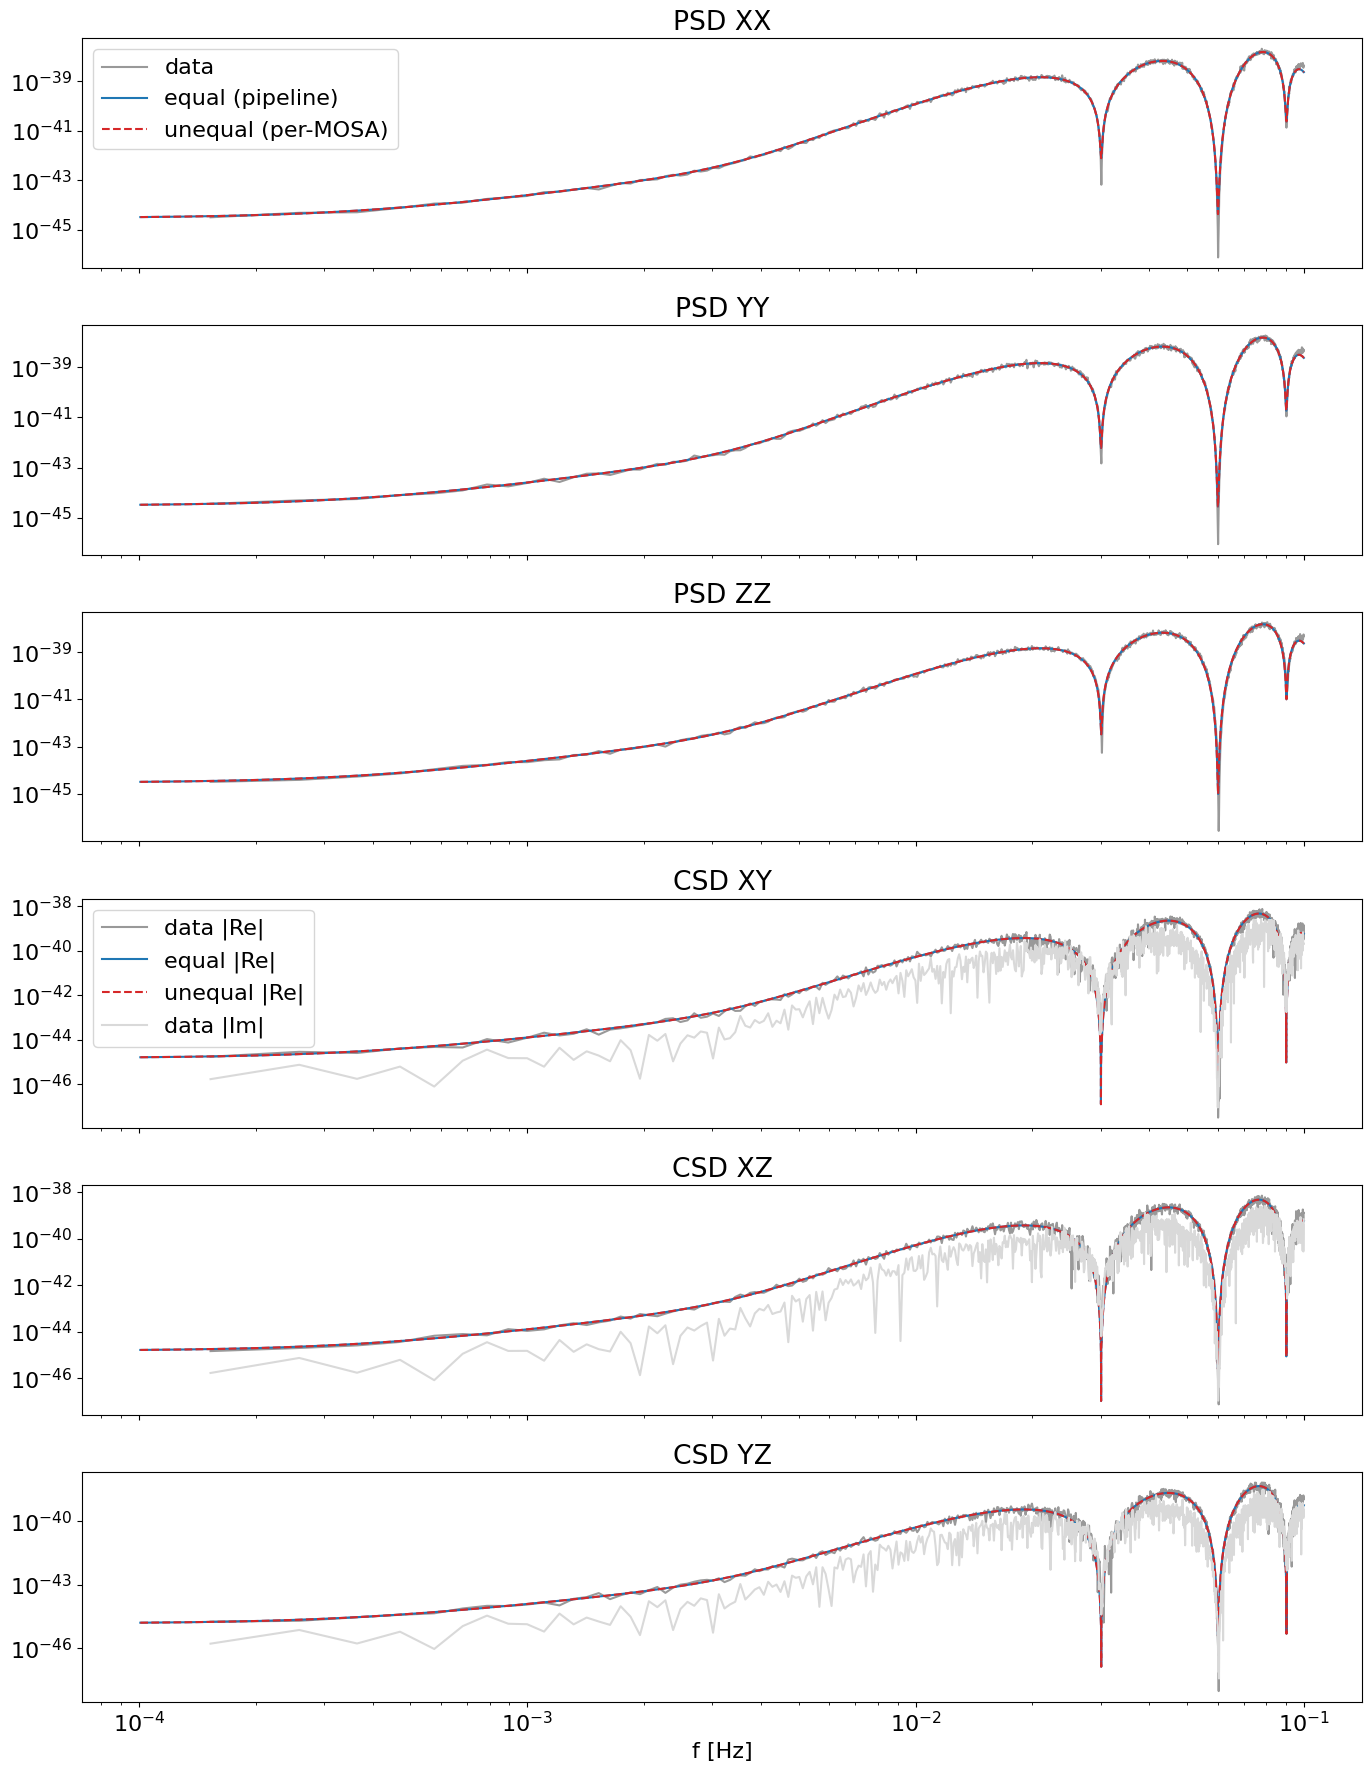

In [24]:
def bin_avg(x, n=64):
    m = (x.shape[-1] // n) * n
    return x[..., :m].reshape(*x.shape[:-1], -1, n).mean(-1)

fb = bin_avg(f)
labels = "XYZ"
pairs_auto = [(0, 0), (1, 1), (2, 2)]
pairs_cross = [(0, 1), (0, 2), (1, 2)]

fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)
for ax, (i, j) in zip(axes[:3], pairs_auto):
    ax.loglog(fb, bin_avg(P_data[i, j].real), color="0.6", label="data")
    ax.loglog(f, C_equal[i, j].real, "C0", label="equal (pipeline)")
    ax.loglog(f, C_unequal[i, j].real, "C3--", label="unequal (per-MOSA)")
    ax.set_title(f"PSD {labels[i]}{labels[j]}")
for ax, (i, j) in zip(axes[3:], pairs_cross):
    ax.loglog(fb, np.abs(bin_avg(P_data[i, j].real)), color="0.6", label="data |Re|")
    ax.loglog(f, np.abs(C_equal[i, j].real), "C0", label="equal |Re|")
    ax.loglog(f, np.abs(C_unequal[i, j].real), "C3--", label="unequal |Re|")
    ax.loglog(fb, np.abs(bin_avg(P_data[i, j].imag)), color="0.85", label="data |Im|")
    ax.set_title(f"CSD {labels[i]}{labels[j]}")
axes[-1].set_xlabel("f [Hz]")
axes[0].legend(); axes[3].legend()
fig.tight_layout()

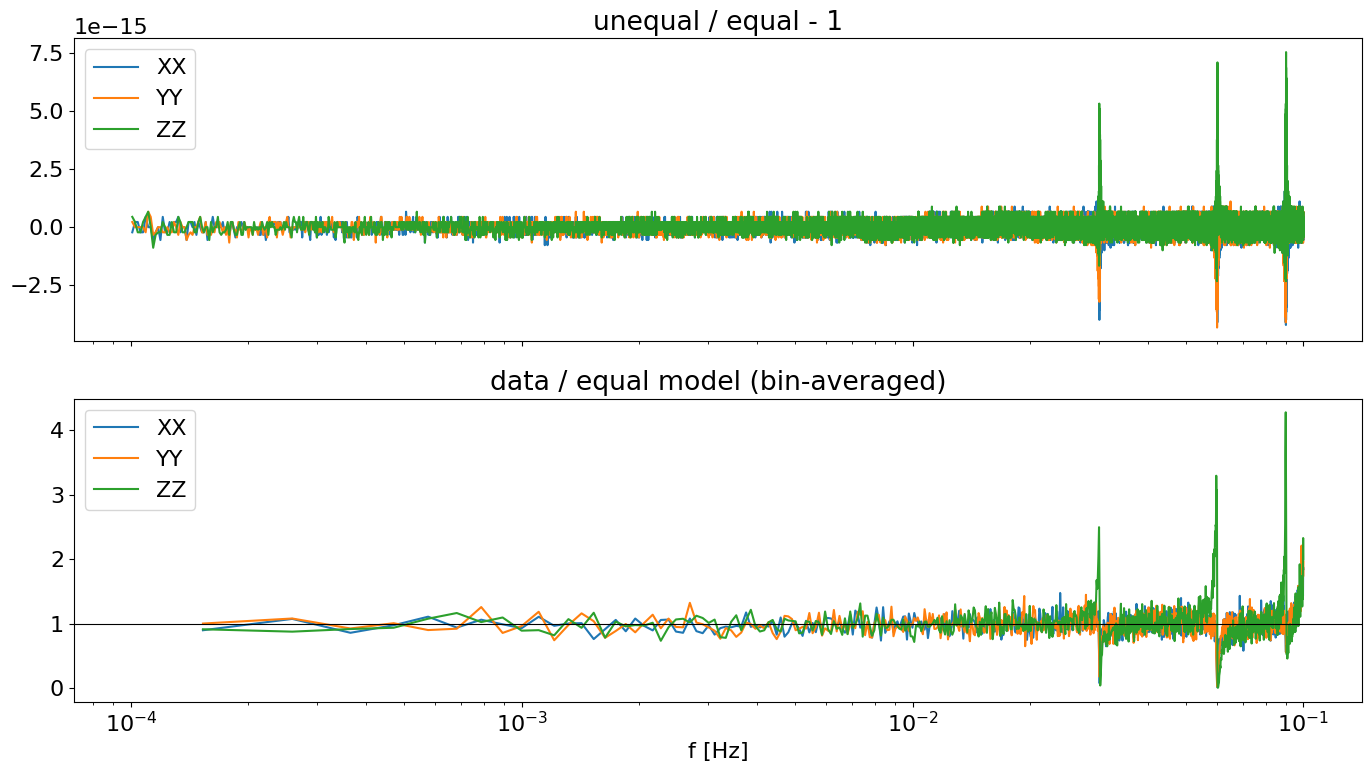

In [25]:
# Model-vs-model and data-vs-model ratios (auto-PSDs)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for (i, j) in pairs_auto:
    axes[0].semilogx(f, C_unequal[i, j].real / C_equal[i, j].real - 1, label=f"{labels[i]}{labels[j]}")
    axes[1].semilogx(fb, bin_avg(P_data[i, j].real) / bin_avg(C_equal[i, j].real), label=f"{labels[i]}{labels[j]}")
axes[0].set_title("unequal / equal - 1")
axes[1].set_title("data / equal model (bin-averaged)")
axes[1].axhline(1, color="k", lw=0.8)
axes[-1].set_xlabel("f [Hz]")
for ax in axes:
    ax.legend()
fig.tight_layout()

## 5. Posterior predictive from sampler runs

Load PSD chains from disk, draw random samples from the cold chain (after burn-in) and evaluate the
noise covariance for each draw on the FD grid above. The reconstructions are summarised by their median
and a quantile band, plotted over the data and the injection model (`C_equal` at the injected `S_OMS`, `S_TM`).

The noise model (symmetric, 2 params, or asymmetric, 12 params) is picked from the chain dimension.
The runs may have used the STFT basis; the amplitudes are basis-independent, so evaluating them on the
FD grid is a fair comparison with the FD periodogram.

In [ ]:
import glob, os
import h5py

RUNS_DIR = "/mnt/wd_hdd_6TB/nikos/DATA/global_fit/gf_output/unequal_noises_preproc-bias/"
BURN_FRAC = 0.5      # fraction of iterations discarded
N_DRAWS = 200        # posterior draws per run
QUANTILES = (0.05, 0.95)
CHUNK = 50           # draws per kernel call (GPU memory)
rng = np.random.default_rng(1234)

def load_psd_chain(path, burn_frac=BURN_FRAC, temp=0):
    """Cold-chain PSD samples, shape (n_samples, ndim)."""
    with h5py.File(path, "r") as fh:
        group = fh["global_fit"] if "global_fit" in fh else fh["mcmc"]
        chain = group["chain/psd"][:, temp, :, 0, :]   # (iter, walker, ndim)
        inds = group["inds/psd"][:, temp, :, 0]
        log_like = group["log_like"][:, temp, :]
        iteration = int(group.attrs["iteration"])
    chain, inds, log_like = chain[:iteration], inds[:iteration], log_like[:iteration]
    start = int(burn_frac * iteration)
    keep = inds[start:]
    return chain[start:][keep], log_like[start:][keep]

run_files = sorted(f for f in glob.glob(os.path.join(RUNS_DIR, "*_main.h5")) if "backup" not in f)
chains = {}
for fp in run_files:
    name = os.path.basename(fp).replace("_parameter_estimation_main.h5", "")
    chains[name], _ = load_psd_chain(fp)
    print(f"{name}: {chains[name].shape[0]} samples, ndim={chains[name].shape[1]}")

psd_unequal_noises_stft: 7500 samples, ndim=12


In [19]:
backends = {2: backend_equal, 2 * len(MOSA_NAMES): backend_unequal}

def posterior_predictive(samples, n_draws=N_DRAWS, chunk=CHUNK):
    """Covariances for random draws, shape (n_draws, 3, 3, Nf)."""
    backend = backends[samples.shape[1]]
    draws = samples[rng.choice(len(samples), size=min(n_draws, len(samples)), replace=False)]
    out = []
    for k in range(0, len(draws), chunk):
        Soms, Sa, _ = backend.split_psd_params(draws[k : k + chunk])
        C = to_np(backend.compute_sensitivity_matrix(Soms, Sa))
        out.append(C.reshape(len(Soms), 3, 3, -1))
    return draws, np.concatenate(out)

ppd = {name: posterior_predictive(s) for name, s in chains.items()}

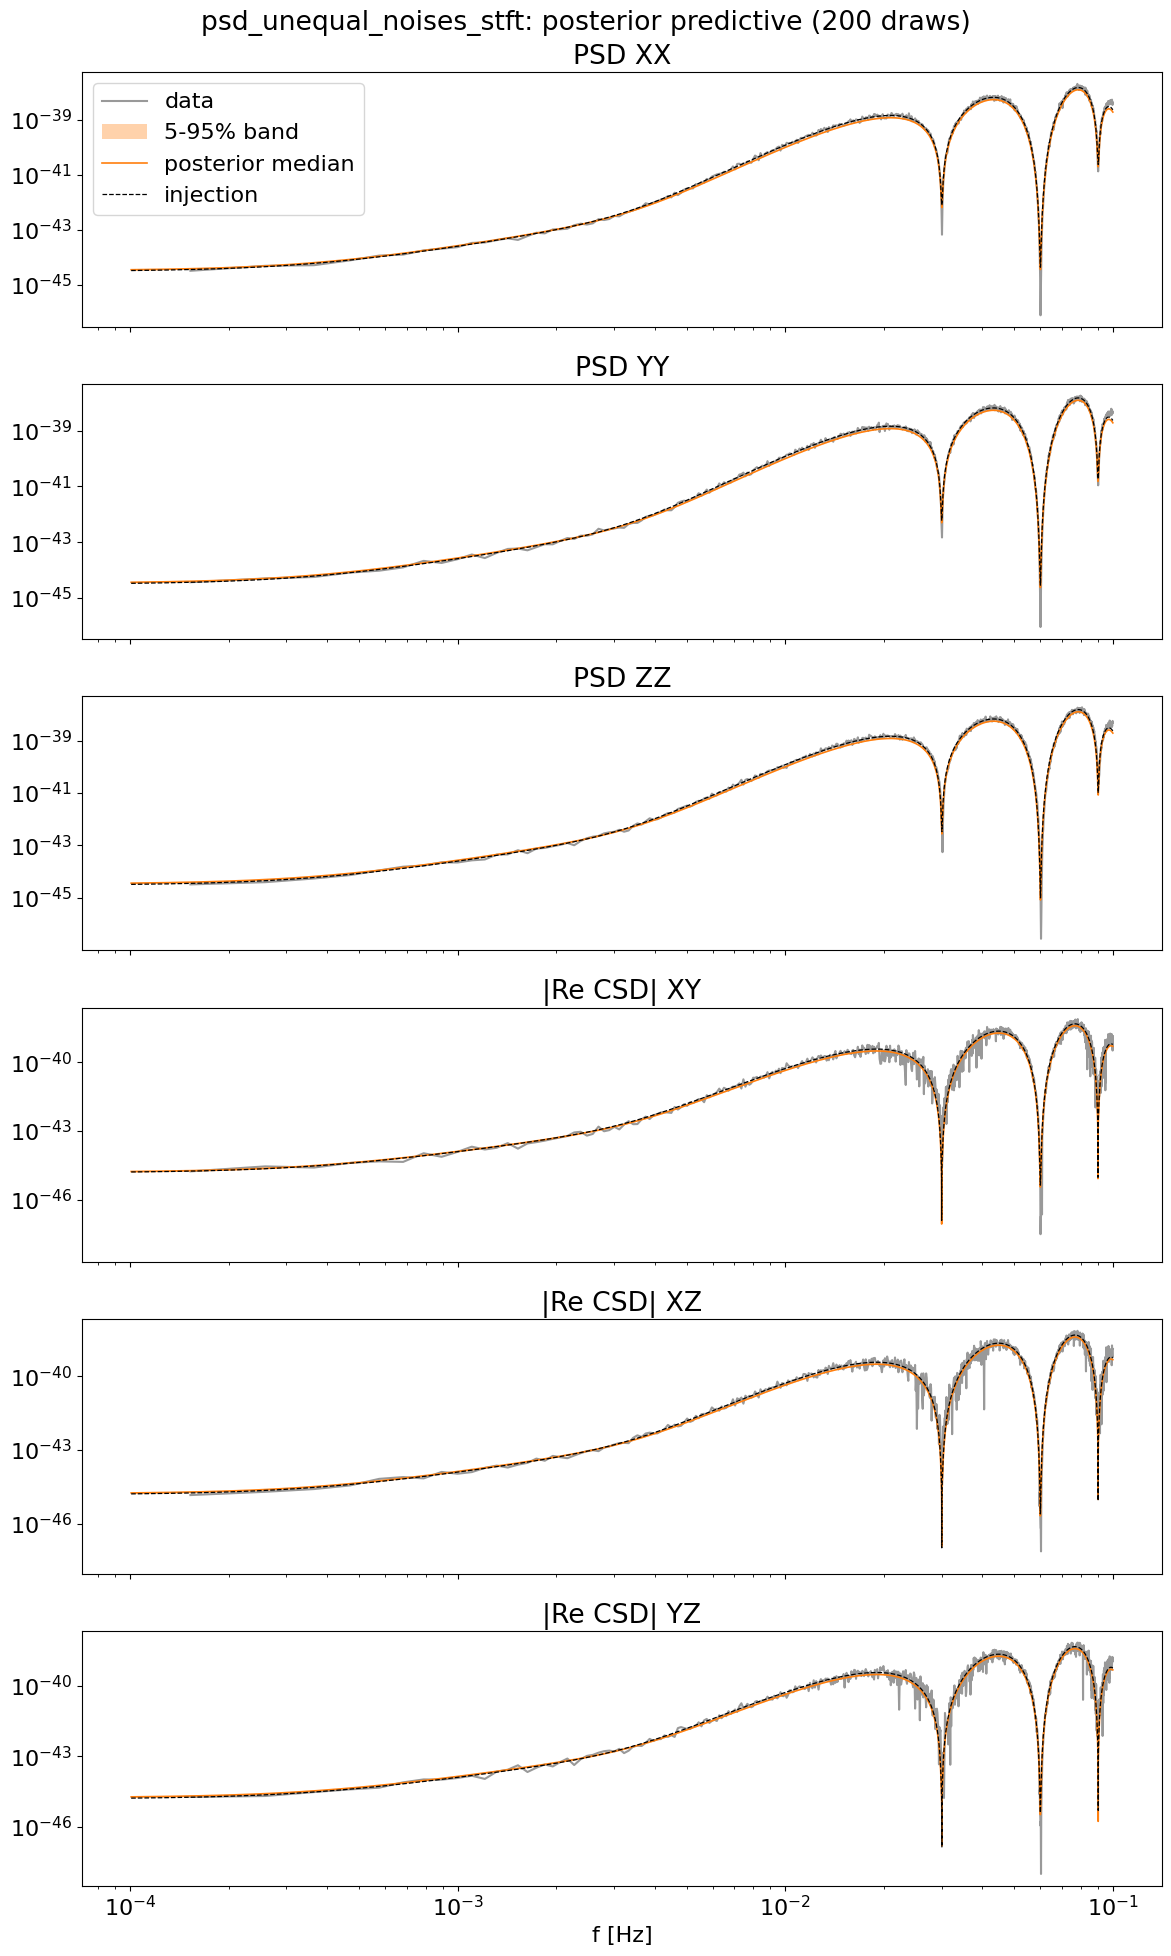

In [27]:
def ppd_bands(C_draws, q=QUANTILES):
    """Median and quantile band of the auto PSDs (real) and |Re| of the CSDs."""
    vals = {}
    for (i, j) in pairs_auto + pairs_cross:
        x = C_draws[:, i, j].real
        x = x if i == j else np.abs(x)
        vals[(i, j)] = (np.median(x, axis=0), *np.quantile(x, q, axis=0))
    return vals

for name, (draws, C_draws) in ppd.items():
    bands = ppd_bands(C_draws)
    fig, axes = plt.subplots(6, 1, figsize=(12, 20), sharex=True)
    for ax, (i, j) in zip(axes.ravel(), pairs_auto + pairs_cross):
        data_ij = bin_avg(P_data[i, j].real)
        inj_ij = C_equal[i, j].real
        if i != j:
            data_ij, inj_ij = np.abs(data_ij), np.abs(inj_ij)
        med, lo, hi = bands[(i, j)]
        ax.loglog(fb, data_ij, color="0.6", label="data")
        ax.fill_between(f, lo, hi, color="C1", alpha=0.35, lw=0,
                        label=f"{int(100 * QUANTILES[0])}-{int(100 * QUANTILES[1])}% band")
        ax.loglog(f, med, "C1", lw=1.2, label="posterior median")
        ax.loglog(f, inj_ij, "k--", lw=0.9, label="injection")
        kind = "PSD" if i == j else "|Re CSD|"
        ax.set_title(f"{kind} {labels[i]}{labels[j]}")
    axes[-1].set_xlabel("f [Hz]")
    axes[0].legend()
    fig.suptitle(f"{name}: posterior predictive ({len(draws)} draws)")
    fig.tight_layout()

Relative deviation of the reconstructions from the injection model (auto PSDs). Values near zero
across the band mean the posterior predictive reproduces the injected spectra, even when the individual
per-MOSA amplitudes are degenerate.

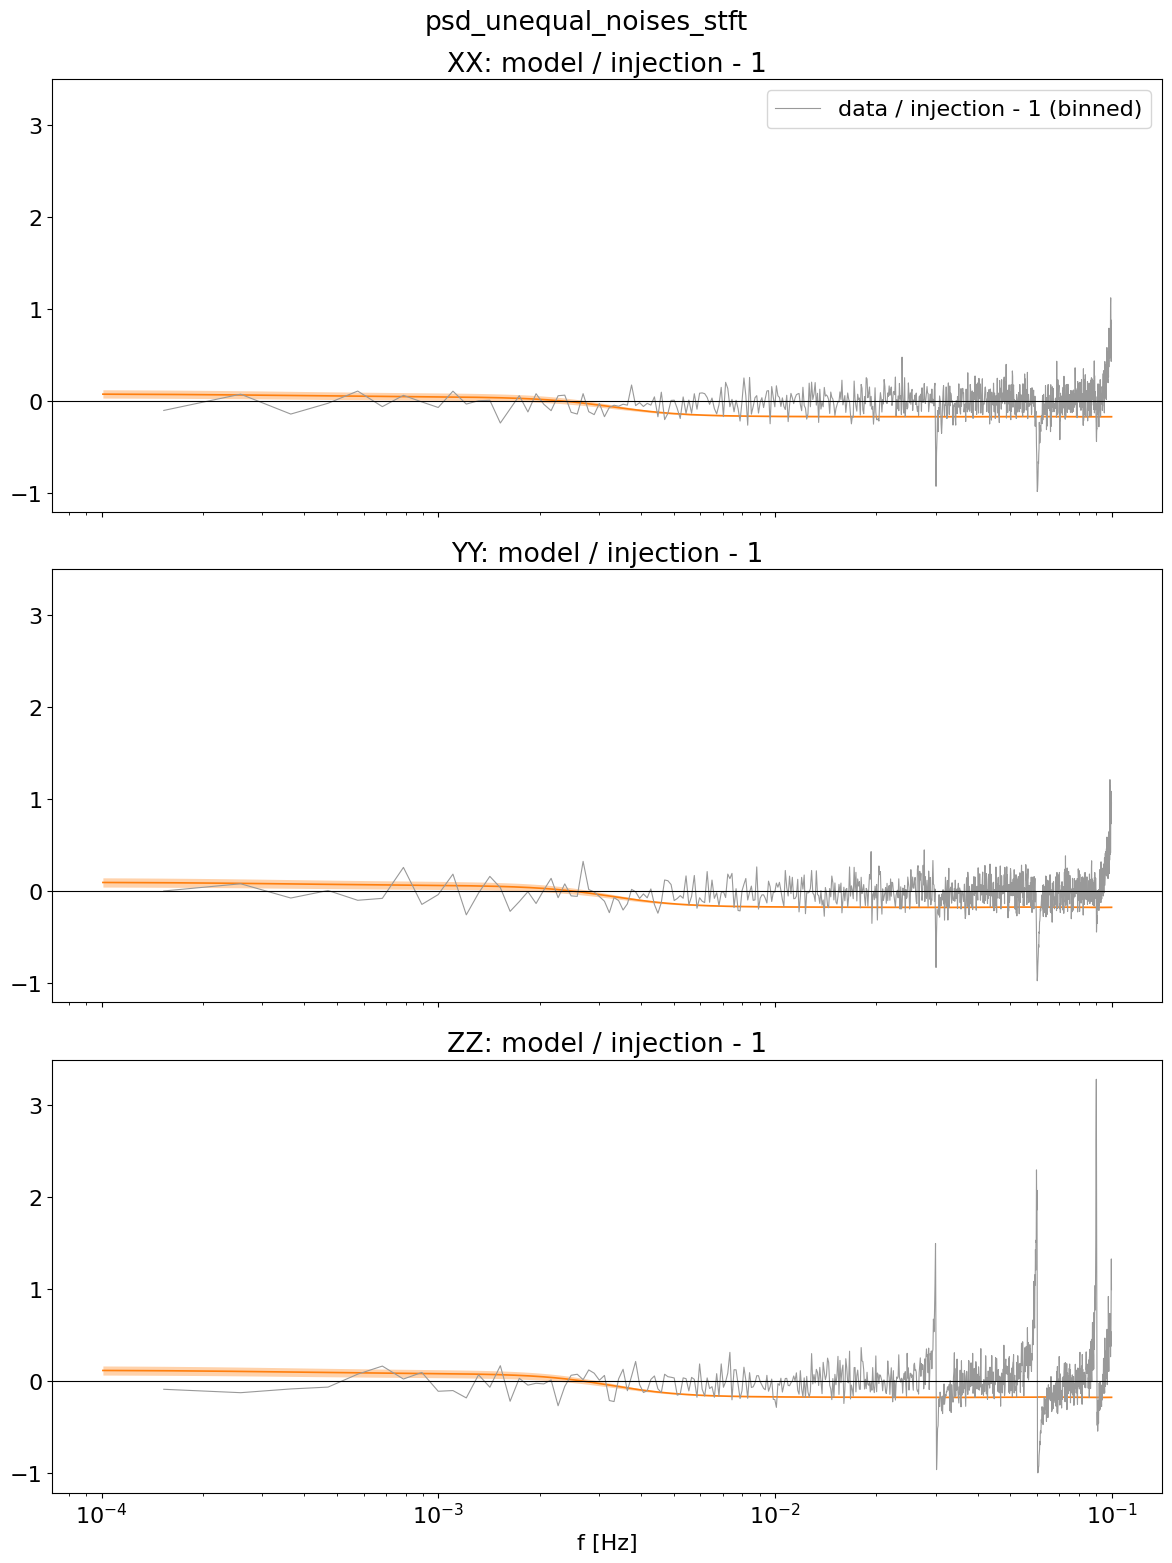

: 

In [ ]:
for name, (draws, C_draws) in ppd.items():
    fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=True, sharey=True)
    for ax, (i, j) in zip(axes, pairs_auto):
        rel = C_draws[:, i, j].real / C_equal[i, j].real - 1
        lo, med, hi = np.quantile(rel, (QUANTILES[0], 0.5, QUANTILES[1]), axis=0)
        ax.fill_between(f, lo, hi, color="C1", alpha=0.35, lw=0)
        ax.semilogx(f, med, "C1", lw=1.2)
        ax.semilogx(fb, bin_avg(P_data[i, j].real) / bin_avg(C_equal[i, j].real) - 1,
                    color="0.6", lw=0.8, label="data / injection - 1 (binned)")
        ax.axhline(0, color="k", lw=0.8)
        ax.set_title(f"{labels[i]}{labels[j]}: model / injection - 1")
    axes[-1].set_xlabel("f [Hz]")
    axes[0].legend()
    fig.suptitle(name)
    fig.tight_layout()

Marginal posteriors of the amplitudes relative to the injection (`S / S_inj`), one box per parameter.

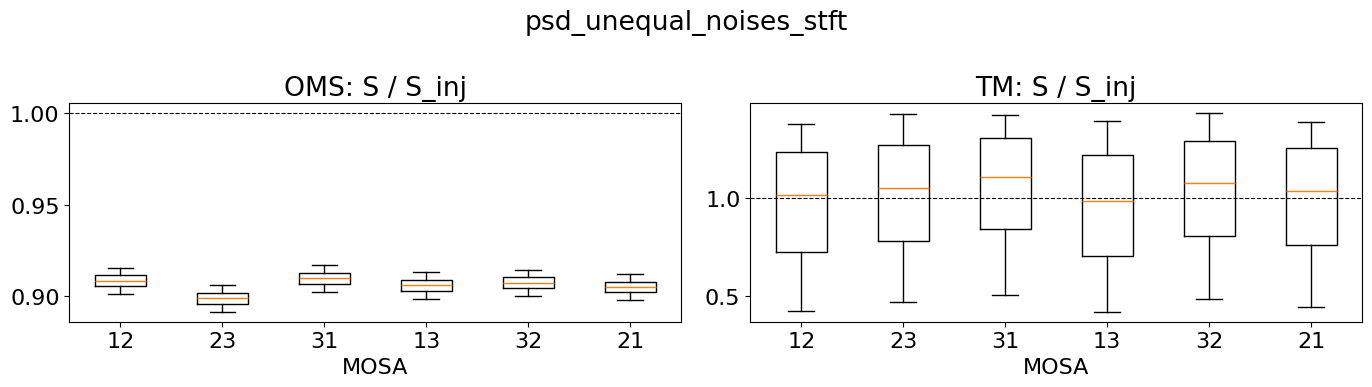

In [22]:
for name, samples in chains.items():
    backend = backends[samples.shape[1]]
    Soms, Sa, _ = backend.split_psd_params(samples)
    Soms, Sa = np.atleast_2d(Soms.T).T, np.atleast_2d(Sa.T).T     # (n_samples, n)
    names = MOSA_NAMES if Soms.shape[1] > 1 else ["all"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, vals, inj, title in ((axes[0], Soms, S_OMS, "OMS"), (axes[1], Sa, S_TM, "TM")):
        ax.boxplot(vals / inj, whis=(5, 95), showfliers=False)
        ax.set_xticks(range(1, len(names) + 1), names)
        ax.axhline(1, color="k", lw=0.8, ls="--")
        ax.set_title(f"{title}: S / S_inj")
        ax.set_xlabel("MOSA")
    fig.suptitle(name)
    fig.tight_layout()